### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:

pd.set_option('display.max_columns',None)
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
#Check the amount of missing data for each column
missing=data.isnull().sum()
print(missing)

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
data = pd.read_csv('data/coupons.csv')
#Ignore NaN values in the car column; removing rows with missing values would delete most of our data. Car column does not seem to be useful so removing
data=data.drop(columns='car')
#Drop Reamaining Missing Values
data=data.dropna()

4. What proportion of the total observations chose to accept the coupon?



In [6]:
#Create dataframe of all individuals who accepted the coupon
accepted=data[data["Y"]==1]
#Use shape to find the number of individuals who accepted
number_accepted=accepted.shape[0]
print('Number of Individuals Who Accepted a Coupon = ' + str(number_accepted))
#Use .shape to find the total number of individuals in the original data
number_total=data.shape[0]
print("Total Number of Individuals Offered a Coupon = "+str(number_total))
#Calculate Proportion
y_proportion=number_accepted/number_total
print("Proportion of Individuals Who Said Yes to the Coupon = "+str(y_proportion))

Number of Individuals Who Accepted a Coupon = 6877
Total Number of Individuals Offered a Coupon = 12079
Proportion of Individuals Who Said Yes to the Coupon = 0.5693352098683666


5. Use a bar plot to visualize the `coupon` column.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Coffee House'),
  Text(1, 0, 'Restaurant(<20)'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

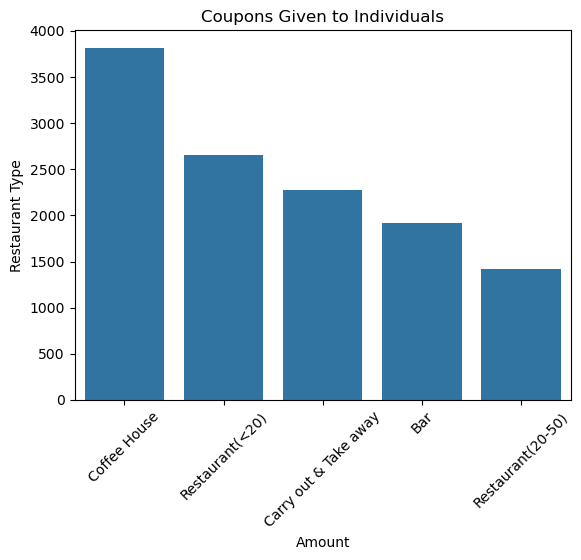

In [7]:
#Use Seaborn to Create a Barplot Showing the Amount of Each Type of Coupon Given
coupon_counts=data['coupon'].value_counts()
sns.barplot(coupon_counts)
#Label and Format Graph Appropriately
plt.title("Coupons Given to Individuals")
plt.xlabel("Amount")
plt.ylabel("Restaurant Type")
plt.xticks(rotation=45)

6. Use a histogram to visualize the temperature column.

Text(0.5, 0, 'Temperature (Degrees F)')

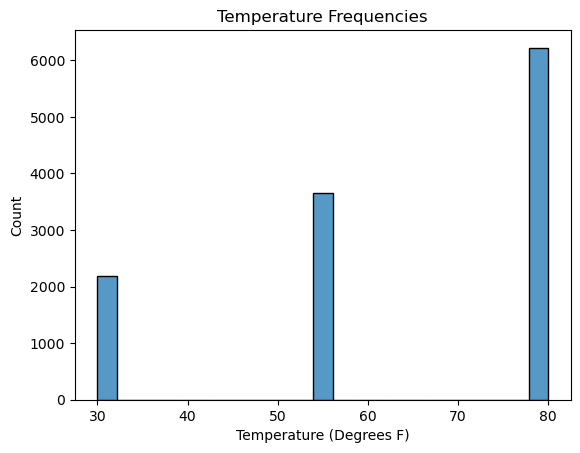

In [8]:
#Create Histogram
sns.histplot(data['temperature'])
#Add Labels
plt.title("Temperature Frequencies")
plt.xlabel("Temperature (Degrees F)")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [9]:
#Create new dataframe with just bar coupons
bar_coupons=data[data['coupon']=='Bar']

2. What proportion of bar coupons were accepted?


In [10]:
#Create a dataframe of all individuals who accepted the coupon
bar_accepted=bar_coupons.query('Y == 1')
#Use .shape to find the number of individuals who accepted
number_bar_accepted=bar_accepted.shape[0]
print("Number of Individuals Who Accepted the Bar Coupon = " +str(number_bar_accepted))
#Use .shape to find the total number of individuals in the original data
number_bar_total=bar_coupons.shape[0]
print("Total Number of Individuals Offered the Bar Coupon = " +str(number_bar_total))
#Calculate Proportion
bar_y_proportion=number_bar_accepted/number_bar_total
print("Proportion of Individuals Who Said Yes to the Bar Coupon = "+str(bar_y_proportion))

Number of Individuals Who Accepted the Bar Coupon = 788
Total Number of Individuals Offered the Bar Coupon = 1913
Proportion of Individuals Who Said Yes to the Bar Coupon = 0.41191845269210664


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [11]:
#Create a dataframe with individuals who go to bars less
bar_less=bar_coupons[(bar_coupons['Bar']=='never') | (bar_coupons['Bar']=='1~3')|(bar_coupons['Bar']=='less1')]
#How many of them said yes?
bar_less_y=bar_less[bar_less['Y']==1]
#Find the Proportion
bar_less_y_ratio=bar_less_y.shape[0]/bar_less.shape[0]
print('Proportion of Individuals Who Go to Bars <3 Times Per Month and Said Yes = '+str(bar_less_y_ratio))
#Do the same thing for those who go more
bar_more=bar_coupons[(bar_coupons['Bar']=='4~8') | (bar_coupons['Bar']=='gt8')]
bar_more_y=bar_more.query('Y==1')
bar_more_y_ratio=bar_more_y.shape[0]/bar_more.shape[0]
print('Proportion of Individuals Who Go to Bars >3 Times Per Month and Said Yes = '+str(bar_more_y_ratio))


Proportion of Individuals Who Go to Bars <3 Times Per Month and Said Yes = 0.37267441860465117
Proportion of Individuals Who Go to Bars >3 Times Per Month and Said Yes = 0.7616580310880829


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [236]:
#Query to get individuals who go to the bar more than once a month
bar_more_than_once=bar_coupons.query('Bar != "never" & Bar!= "less1"')
#Find 
bar_more_than_once_y=bar_more_than_once.query('Y==1')
bar_mto_ratio=bar_more_than_once_y.shape[0]/bar_more_than_once.shape[0]
print("Ratio of Bargoers Who Said Yes = "+str(bar_mto_ratio))
#Query for Older Individuals
bar_more_than_once_old=bar_more_than_once.query('age!="below21" & age!="21"')
#Query for Older Individuals who said yes
bar_mto_o_y=bar_more_than_once_old.query('Y==1')
#Find Ratio for Older individuals
bar_mto_o_y_ratio=bar_mto_o_y.shape[0]/bar_more_than_once_old.shape[0]
print("Ratio of Bargoers >25 yrs old Who Accepted the Coupon = "+str(bar_mto_o_y_ratio))
#Query for Younger Individuals
bar_more_than_once_young=bar_more_than_once.query('age=="below21" | age=="21"')
#Query for Younger Individuals who said yes
bar_mto_y_y=bar_more_than_once_young.query('Y==1')
#Find Ratio for Younger individuals
bar_mto_y_y_ratio=bar_mto_y_y.shape[0]/bar_more_than_once_young.shape[0]
print("Ratio of Bargoers <25 yrs old Who Accepted the Coupon = "+str(bar_mto_y_y_ratio))


Ratio of Bargoers Who Said Yes = 0.6774716369529984
Ratio of Bargoers >25 yrs old Who Accepted the Coupon = 0.6818181818181818
Ratio of Bargoers <25 yrs old Who Accepted the Coupon = 0.6666666666666666


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [234]:
#Create dataframe of the group
group5=bar_coupons.query('occupation!="farming" & occupation!="fishing" & occupation != "forestry"').query('Bar != "never" & Bar!= "less1"')
no_kid=group5.query('passanger!="Kid(s)"& passanger!="Alone"')
#Query for those who said yes
no_kid_y=no_kid.query('Y==1')
#Compare Ratios
no_kid_ratio=no_kid_y.shape[0]/no_kid.shape[0]
print('Ratio of Group that Accepted = ' +str(no_kid_ratio))

Ratio of Group that Accepted = 0.7073170731707317


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
#The Individuals who accepted the bar coupons were primarily those who already went to bars at least once a month. It does not seem like age is a 
#Significant factor. The data suggests that individuals are also slightly more likely to go to the bar if there is no child present
#From the data, it seems that the frequency one goes to the bar is the largest factor in determining if they accepted the coupon.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [ ]:
#I am choosing to examine individuals who accepted the coffee house coupons

In [15]:
#Dataframe of Coffee Drinkers
coffee=data.query('coupon == "Coffee House"')
#Analyze overall acceptance rate
coffee_yes=coffee.query('Y==1')
coffee_yes_ratio=coffee_yes.shape[0]/coffee.shape[0]
print(coffee_yes_ratio)

0.49633123689727465


Text(0.5, 1.0, 'Coffee Coupon Acceptance Rate for Different Times of Day')

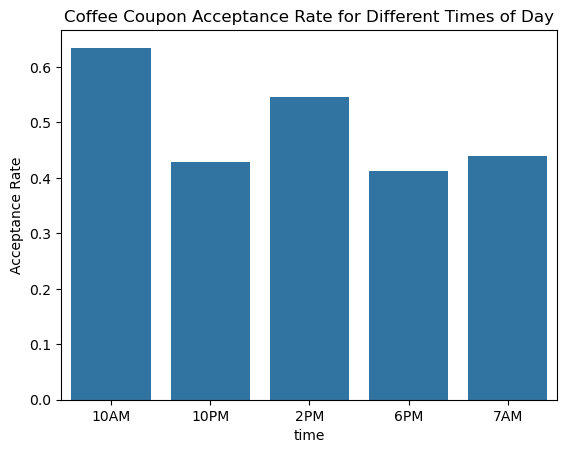

In [37]:
#Analyze how the time of day affected coupon acceptance
time_group=coffee.groupby('time')[['time']].value_counts()
time_accepted=coffee.groupby('time').agg({'Y':'sum'})
#Calculate Ratio
coffee_ratios=time_accepted['Y']/time_group
#Plot
sns.barplot(coffee_ratios)
plt.ylabel('Acceptance Rate')
plt.title('Coffee Coupon Acceptance Rate for Different Times of Day')

Text(0, 0.5, 'Acceptance Rate for Coffee House Coupons')

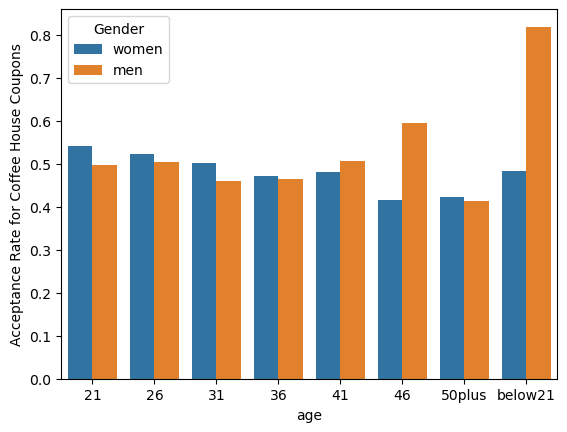

In [104]:
#Analyze how age and gender affect acceptance

#Men
men=coffee.query('gender=="Male"')
men_ages=men.groupby('age')[['age']].value_counts()
men_ages_y=men.groupby('age').agg({'Y':'sum'})
men_ages_y['total']=men_ages
men_ages_y['men']=men_ages_y['Y']/men_ages_y['total']

#Women
women=coffee.query('gender=="Female"')
women_ages=women.groupby('age')[['age']].value_counts()
women_ages_y=women.groupby('age').agg({'Y':'sum'})
women_ages_y['total']=women_ages
women_ages_y['women']=women_ages_y['Y']/women_ages_y['total']

#Merge DataFrames
both_genders=pd.merge(left=women_ages_y,right=men_ages_y,left_on='age',right_on='age')
both_genders=both_genders[['women','men']]
both_genders['age']=both_genders.index

#Create a barplot comparing age groups and genders
both_genders_long = both_genders.melt(id_vars='age', value_vars=['women', 'men'], var_name='Gender', value_name='Value')
sns.barplot(data=both_genders_long, x='age', y='Value', hue='Gender')
plt.ylabel("Acceptance Rate for Coffee House Coupons")

In [114]:
#Examine how the destination affects the acceptance rate
dest=coffee.groupby("destination")[['destination']].value_counts()
dest_yes=coffee.groupby("destination").agg({'Y':'sum'})
dest_yes['total']=dest
dest_yes['ratio']=dest_yes['Y']/dest_yes['total']
print(dest_yes)


                    Y  total     ratio
destination                           
Home              322    888  0.362613
No Urgent Place  1187   2053  0.578178
Work              385    875  0.440000
